In [1]:
import os
import shutil
from sklearn.model_selection import train_test_split
import random

random.seed(42)

# Chemin dossier source (images classées par sous-dossiers de classes)
base_dir = r"C:\Users\DELL\Desktop\dataimagesattelite"

# Chemin dossier destination (où les dossiers train/val/test seront créés)
output_dir = r"C:\Users\DELL\Desktop\EuroSAT_split"

# Ratios pour le split
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Créer les dossiers train/val/test + sous dossiers classes
for split in ['train', 'val', 'test']:
    split_dir = os.path.join(output_dir, split)
    os.makedirs(split_dir, exist_ok=True)
    for class_name in os.listdir(base_dir):
        class_dir = os.path.join(split_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)

# Pour chaque classe, lister les images et les répartir dans train/val/test
for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(images)

    # Split train / temp (val+test)
    train_imgs, temp_imgs = train_test_split(images, test_size=(1 - train_ratio), random_state=42)
    # Split temp en val et test
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=test_ratio/(val_ratio + test_ratio), random_state=42)

    # Copier dans le dossier train
    for img in train_imgs:
        src = os.path.join(class_path, img)
        dst = os.path.join(output_dir, 'train', class_name, img)
        shutil.copy2(src, dst)

    # Copier dans le dossier val
    for img in val_imgs:
        src = os.path.join(class_path, img)
        dst = os.path.join(output_dir, 'val', class_name, img)
        shutil.copy2(src, dst)

    # Copier dans le dossier test
    for img in test_imgs:
        src = os.path.join(class_path, img)
        dst = os.path.join(output_dir, 'test', class_name, img)
        shutil.copy2(src, dst)

    print(f"{class_name}: train={len(train_imgs)}, val={len(val_imgs)}, test={len(test_imgs)}")

print("✅ Répartition train/val/test terminée.")

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

img_size = (128, 128)
batch_size = 32

# Data augmentation uniquement pour train
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

# Pas d'augmentation pour val et test, juste préprocessing
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    r"C:\Users\DELL\Desktop\EuroSAT_split\train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    r"C:\Users\DELL\Desktop\EuroSAT_split\val",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    r"C:\Users\DELL\Desktop\EuroSAT_split\test",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='sparse',
    shuffle=False
)

✅ Répartition train/val/test terminée.
Found 18890 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.
Found 4060 images belonging to 10 classes.


Found 18890 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.
Found 4060 images belonging to 10 classes.
Classes: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}
Train samples: 18890
Validation samples: 4050
Test samples: 4060
🚀 Démarrage de l'entraînement accéléré...
⏰ Temps estimé: 15-30 minutes
=== ENTRAÎNEMENT RAPIDE ===
Epoch 1/15
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8586 - loss: 0.4984

295/295 ━━━━━━━━━━━━━━━━━━━━ 831s 3s/step - accuracy: 0.8587 - loss: 0.4977 - val_accuracy: 0.9395 - val_loss: 0.1855
Epoch 2/15
  1/295 ━━━━━━━━━━━━━━━━━━━━ 8:53 2s/step - accuracy: 0.9219 - loss: 0.3413

c:\Users\DELL\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


295/295 ━━━━━━━━━━━━━━━━━━━━ 122s 408ms/step - accuracy: 0.9219 - loss: 0.3413 - val_accuracy: 0.9417 - val_loss: 0.1828
Epoch 3/15
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9548 - loss: 0.1328

295/295 ━━━━━━━━━━━━━━━━━━━━ 513s 2s/step - accuracy: 0.9548 - loss: 0.1328 - val_accuracy: 0.9432 - val_loss: 0.1789
Epoch 4/15
295/295 ━━━━━━━━━━━━━━━━━━━━ 87s 291ms/step - accuracy: 1.0000 - loss: 0.0424 - val_accuracy: 0.9415 - val_loss: 0.1809
Epoch 5/15
295/295 ━━━━━━━━━━━━━━━━━━━━ 489s 2s/step - accuracy: 0.9658 - loss: 0.0957 - val_accuracy: 0.9392 - val_loss: 0.1994
Epoch 6/15
295/295 ━━━━━━━━━━━━━━━━━━━━ 88s 295ms/step - accuracy: 1.0000 - loss: 0.0141 - val_accuracy: 0.9385 - val_loss: 0.2017
=== ÉVALUATION RAPIDE ===


Test accuracy: 0.9411
Test loss: 0.1764
Modèle rapide sauvegardé!


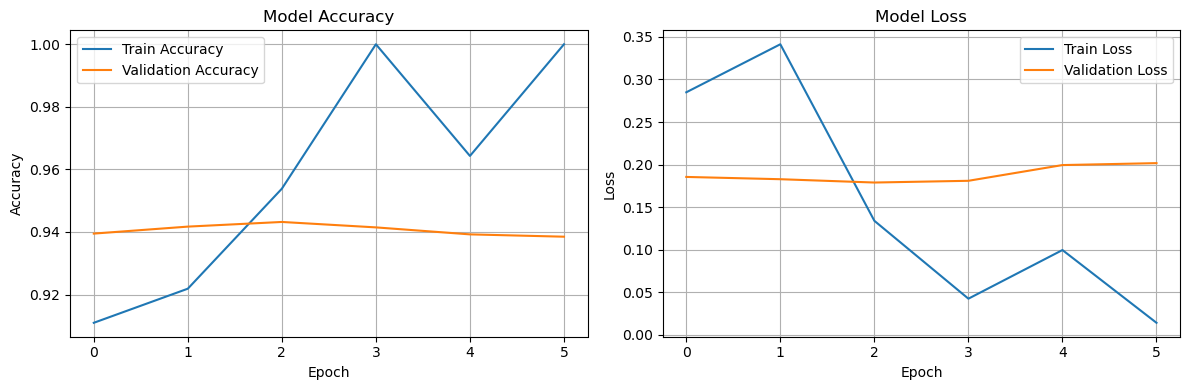


=== RÉSULTATS RAPIDES ===
Accuracy finale - Validation: 0.9432
Modèle prêt à être utilisé dans les applications!
